In [573]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from statsforecast import StatsForecast, models
import plotly.graph_objects as go

# Подготовка датасетов к анализу

In [574]:
df = pd.read_csv('top_lvl_combined_f.csv').drop(columns=['Unnamed: 0'])
df['date'] = pd.to_datetime(df['date'])
df.head()


,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
0,OZON,2023-01-31,Ozon fresh,7.267095e+08,1018707.0,10909.0,3270.0,525.0,1692.0
1,OZON,2023-02-28,Ozon fresh,1.535720e+09,1342474.0,2439.0,2318.0,326.0,399.0
2,OZON,2023-03-31,Ozon fresh,1.917223e+09,1884459.0,11701.0,3570.0,494.0,1660.0
3,OZON,2023-04-30,Ozon fresh,3.227949e+09,3666176.0,15484.0,4720.0,741.0,2047.0
4,OZON,2023-05-31,Ozon fresh,4.234719e+09,4125418.0,25133.0,7917.0,1375.0,2924.0


In [575]:
df['category'].unique()

array(['Ozon fresh', 'Автомобили', 'Автотовары', 'Автотовар�',
       'Автотова�ы', 'Автотов�ры', 'Автото�ары', 'Автот�вары',
       'Авто�овары', 'Авт�товары', 'Ав�отовары', 'Аксессуары',
       'Аксессуар�', 'Аксессу�ры', 'Аксес�уары', 'Ак�ессуары',
       'Антиквариат и коллекционирование',
       'Антиквариат и коллекц�онирование',
       'Антикв�риат и коллекционирование', 'Аптека', 'А�тотовары',
       'Билеты, отели, туры', 'Бытовая техника', 'Бытовая техни�а',
       'Бытовая те�ника', 'Бытовая химия и гигиена',
       'Бытовая химия и ги�иена', 'Бытовая хи�ия и гигиена',
       'Бытовая �ехника', 'Бытова� техника', 'Б�товая техника',
       'Детские товары', 'Детские това�ы', 'Детские т�вары',
       'Детск�е товары', 'Дом и сад', 'Дом и �ад', 'Дом � сад',
       'До� и сад', 'Игры и консоли', 'Канцелярские товары',
       'Канцелярские то�ары', 'Канцелярски� товары',
       'Канцел�рские товары', 'Книги', 'Книг�', 'Кни�и',
       'Красота и здоровье', 'Красота и здоров�е', 'К

Из-за парсинга некоторые категории названы некорректно, исправим это:

In [576]:
# Выбираем уникальные категории
categories = df['category'].unique()

# Выбираем категории без символа '�' — это "правильные" категории
valid_categories = set(cat for cat in categories if '�' not in cat)

# "Сломанные" категории содержат '�'
broken_categories = [cat for cat in categories if '�' in cat]

import difflib

# Словарь: "сломанная" категория -> "исправленная"
category_mapping = {}

for broken_cat in broken_categories:
    # Находим наиболее похожую правильную категорию
    matches = difflib.get_close_matches(broken_cat, valid_categories, n=1, cutoff=0.5)
    if matches:
        category_mapping[broken_cat] = matches[0]

# Заменяем с помощью map с аргументом category_mapping
df_fixed = df.copy()

df_fixed['category'] = df['category'].replace(category_mapping)

In [577]:
df_fixed['category'].unique()

array(['Ozon fresh', 'Автомобили', 'Автотовары', 'Аксессуары',
       'Антиквариат и коллекционирование', 'Аптека',
       'Билеты, отели, туры', 'Бытовая техника',
       'Бытовая химия и гигиена', 'Детские товары', 'Дом и сад',
       'Игры и консоли', 'Канцелярские товары', 'Книги',
       'Красота и здоровье', 'Мебель', 'Музыка и видео', 'Обувь',
       'Одежда', 'Продукты питания', 'Спорт и отдых',
       'Строительство и ремонт', 'Товары для взрослых',
       'Товары для животных', 'Товары для курения и аксессуары',
       'Туризм, рыбалка, охота', 'Хобби и творчество', 'Цифровые товары',
       'Электроника', 'Электронные сигареты и товары для курения',
       'Ювелирные украшения', 'Детям', 'Для ремонта', 'Дом', 'Женщинам',
       'Здоровье', 'Зоотовары', 'Игрушки', 'Канцтовары', 'Красота',
       'Культурный код', 'Лекарственные препараты', 'Мужчинам',
       'Народные Промыслы', 'Новый год', 'Продукты', 'Сад и дача',
       'Сделано в Москве', 'Сделано в России', 'Спорт',
   

Теперь катеогрии названы правильно. Для начала мы хотим разделить наш датасет на 3 датасета для разных маркетплейсов.

In [578]:
df_fixed['marketplace'].unique()

array(['OZON', 'Wildberries', 'Яндекс.Маркет'], dtype=object)

In [579]:
ozon = df_fixed[df_fixed['marketplace'] == 'OZON'].copy()
wb = df_fixed[df_fixed['marketplace'] == 'Wildberries'].copy()
yand_market = df_fixed[df_fixed['marketplace'] == 'Яндекс.Маркет'].copy()
numeric_cols = ['revenue_rub', 'goods', 'goods with sales', 'sales', 'sellers', 'brands']

In [580]:
ozon[ozon['category']=='Автомобили']

,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
26,OZON,2023-10-31,Автомобили,0.0,0.0,107.0,0.0,3.0,2.0
27,OZON,2023-11-30,Автомобили,0.0,0.0,132.0,0.0,2.0,3.0
28,OZON,2023-12-31,Автомобили,0.0,0.0,119.0,0.0,6.0,13.0
29,OZON,2024-01-31,Автомобили,0.0,0.0,180.0,0.0,10.0,15.0
30,OZON,2024-02-29,Автомобили,0.0,0.0,244.0,0.0,12.0,18.0
31,OZON,2024-03-31,Автомобили,0.0,0.0,483.0,0.0,29.0,25.0
32,OZON,2024-04-30,Автомобили,0.0,0.0,609.0,0.0,42.0,33.0
33,OZON,2024-05-31,Автомобили,0.0,0.0,799.0,0.0,52.0,47.0
34,OZON,2024-06-30,Автомобили,0.0,0.0,1004.0,0.0,55.0,47.0
35,OZON,2024-07-31,Автомобили,0.0,0.0,1229.0,0.0,66.0,53.0


Далее перед нами стоит задача выделить одинаковые категории товаров для всех маркетплейсах, чтобы далее была возможность сравнить данные.

In [581]:
sorted(yand_market['category'].unique())

['Авто',
 'Аптека',
 'Бытовая техника',
 'Дача, сад и огород',
 'Детские товары',
 'Досуг и развлечения',
 'Книги',
 'Компьютерная техника',
 'Оборудование',
 'Одежда, обувь и аксессуары',
 'Продукты',
 'Спорт и отдых',
 'Строительство и ремонт',
 'Товары для дома',
 'Товары для животных',
 'Товары для красоты',
 'Упаковочные материалы для Беру',
 'Цветы, букеты, композиции',
 'Электроника']

In [582]:
sorted(wb['category'].unique())

['Автотовары',
 'Аксессуары',
 'Бытовая техника',
 'Детям',
 'Для ремонта',
 'Дом',
 'Женщинам',
 'Здоровье',
 'Зоотовары',
 'Игрушки',
 'Канцтовары',
 'Книги',
 'Красота',
 'Культурный код',
 'Лекарственные препараты',
 'Мебель',
 'Мужчинам',
 'Народные Промыслы',
 'Новый год',
 'Обувь',
 'Продукты',
 'Сад и дача',
 'Сделано в Москве',
 'Сделано в России',
 'Спорт',
 'Товары для взрослых',
 'Транспортные средства',
 'Цветы',
 'Школа',
 'Электроника',
 'Ювелирные изделия']

In [583]:
sorted(ozon['category'].unique())

['Ozon fresh',
 'Автомобили',
 'Автотовары',
 'Аксессуары',
 'Антиквариат и коллекционирование',
 'Аптека',
 'Билеты, отели, туры',
 'Бытовая техника',
 'Бытовая химия и гигиена',
 'Детские товары',
 'Дом и сад',
 'Игры и консоли',
 'Канцелярские товары',
 'Книги',
 'Красота и здоровье',
 'Мебель',
 'Музыка и видео',
 'Обувь',
 'Одежда',
 'Продукты питания',
 'Спорт и отдых',
 'Строительство и ремонт',
 'Товары для взрослых',
 'Товары для животных',
 'Товары для курения и аксессуары',
 'Туризм, рыбалка, охота',
 'Хобби и творчество',
 'Цифровые товары',
 'Электроника',
 'Электронные сигареты и товары для курения',
 'Ювелирные украшения']

Следующий этап подготовки данных - переименовать категории, которые имеют синонимичные названия.

In [584]:
yand_market.loc[yand_market['category'] == 'Авто', 'category'] = 'Автотовары'
yand_market.loc[yand_market['category'] == 'Товары для животных', 'category'] = 'Зоотовары'
yand_market.sort_values("category")

,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
1504,Яндекс.Маркет,2023-01-31,Автотовары,1.354254e+09,547056.0,166844.0,166844.0,6283.0,4318.0
1530,Яндекс.Маркет,2025-03-31,Автотовары,4.889137e+09,1166368.0,317877.0,317877.0,11071.0,8110.0
1529,Яндекс.Маркет,2025-02-28,Автотовары,2.415778e+09,749563.0,256919.0,256919.0,10842.0,7670.0
1528,Яндекс.Маркет,2025-01-31,Автотовары,2.016643e+09,678988.0,234014.0,234014.0,10327.0,7136.0
1527,Яндекс.Маркет,2024-12-31,Автотовары,2.444071e+09,803631.0,244969.0,244969.0,10861.0,6930.0
...,...,...,...,...,...,...,...,...,...
1965,Яндекс.Маркет,2023-02-28,Электроника,1.323967e+10,1068172.0,205800.0,205800.0,6905.0,3734.0
1964,Яндекс.Маркет,2023-01-31,Электроника,1.423198e+10,1019386.0,199188.0,199188.0,6413.0,3568.0
1989,Яндекс.Маркет,2025-02-28,Электроника,2.033317e+10,1565569.0,275709.0,275709.0,11396.0,5930.0
1976,Яндекс.Маркет,2024-01-31,Электроника,1.435935e+10,1372312.0,235264.0,235264.0,9631.0,3750.0


In [585]:
wb[wb['category']=='Лекарственные препараты']

,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
1220,Wildberries,2025-03-31,Лекарственные препараты,200.0,1.0,6877.0,1.0,3.0,995.0


Замечаем, что категория "Лекарственные препараты", которую можно было бы переименовать в "Аптеку" имеет только одну временную точку в датасете, значит, данную категорию придется исключить. Вместо этого можно таким образом переименовать категорию "Здоровье".

In [586]:
wb[wb['category']=='Здоровье']

,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
1054,Wildberries,2023-01-31,Здоровье,6.532970e+09,6985853.0,486820.0,181468.0,28557.0,38856.0
1055,Wildberries,2023-02-28,Здоровье,7.493698e+09,7504197.0,497404.0,188087.0,29022.0,38944.0
1056,Wildberries,2023-03-31,Здоровье,9.670175e+09,7743387.0,564669.0,205762.0,30347.0,40270.0
1057,Wildberries,2023-04-30,Здоровье,1.047732e+10,8320004.0,577079.0,210008.0,30554.0,40209.0
1058,Wildberries,2023-05-31,Здоровье,1.144733e+10,9149975.0,575424.0,216643.0,30010.0,38997.0
1059,Wildberries,2023-06-30,Здоровье,1.208699e+10,9729905.0,549074.0,220003.0,31718.0,39285.0
1060,Wildberries,2023-07-31,Здоровье,1.127003e+10,9476668.0,577829.0,240066.0,46991.0,38669.0
1061,Wildberries,2023-08-31,Здоровье,1.465400e+10,10542060.0,573045.0,245087.0,44854.0,38749.0
1062,Wildberries,2023-09-30,Здоровье,1.479393e+10,10506468.0,462260.0,227438.0,29726.0,35465.0
1063,Wildberries,2023-10-31,Здоровье,1.831714e+10,11996187.0,446543.0,218118.0,29824.0,36246.0


In [587]:
wb.loc[wb['category'] == 'Здоровье', 'category'] = 'Аптека'
wb.loc[wb['category'] == 'Спорт', 'category'] = 'Спорт и отдых'
wb.sort_values("category")

,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
872,Wildberries,2023-01-31,Автотовары,1.517288e+09,1722906.0,1393574.0,116331.0,19799.0,28690.0
897,Wildberries,2025-03-31,Автотовары,7.342222e+09,7266146.0,11614252.0,400243.0,38110.0,57471.0
896,Wildberries,2025-02-28,Автотовары,7.638172e+09,7496119.0,10409969.0,379129.0,37599.0,59162.0
895,Wildberries,2025-01-31,Автотовары,5.611638e+09,5716055.0,9536772.0,380768.0,36556.0,59353.0
894,Wildberries,2024-12-31,Автотовары,7.385055e+09,7110419.0,9712537.0,391107.0,37533.0,63865.0
...,...,...,...,...,...,...,...,...,...
1479,Wildberries,2023-02-28,Ювелирные изделия,2.172597e+09,875795.0,158064.0,84679.0,2430.0,2738.0
1478,Wildberries,2023-01-31,Ювелирные изделия,1.968838e+09,775809.0,158299.0,84915.0,2519.0,2893.0
1502,Wildberries,2025-02-28,Ювелирные изделия,3.164533e+09,1566681.0,127045.0,69004.0,1355.0,1584.0
1489,Wildberries,2023-12-31,Ювелирные изделия,2.533942e+09,1143546.0,111190.0,64142.0,1188.0,1426.0


In [588]:
ozon[ozon['category']=='Автомобили']

,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
26,OZON,2023-10-31,Автомобили,0.0,0.0,107.0,0.0,3.0,2.0
27,OZON,2023-11-30,Автомобили,0.0,0.0,132.0,0.0,2.0,3.0
28,OZON,2023-12-31,Автомобили,0.0,0.0,119.0,0.0,6.0,13.0
29,OZON,2024-01-31,Автомобили,0.0,0.0,180.0,0.0,10.0,15.0
30,OZON,2024-02-29,Автомобили,0.0,0.0,244.0,0.0,12.0,18.0
31,OZON,2024-03-31,Автомобили,0.0,0.0,483.0,0.0,29.0,25.0
32,OZON,2024-04-30,Автомобили,0.0,0.0,609.0,0.0,42.0,33.0
33,OZON,2024-05-31,Автомобили,0.0,0.0,799.0,0.0,52.0,47.0
34,OZON,2024-06-30,Автомобили,0.0,0.0,1004.0,0.0,55.0,47.0
35,OZON,2024-07-31,Автомобили,0.0,0.0,1229.0,0.0,66.0,53.0


Видим, что эта категория некорретна, так как продажи есть, а выручки нет, не будем ее добавлять в наш итоговый датасет.

In [589]:
ozon.loc[ozon['category'] == 'Продукты питания', 'category'] = 'Продукты'
ozon.loc[ozon['category'] == 'Товары для животных', 'category'] = 'Зоотовары'
ozon.sort_values("category")

,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
0,OZON,2023-01-31,Ozon fresh,7.267095e+08,1018707.0,10909.0,3270.0,525.0,1692.0
25,OZON,2025-03-31,Ozon fresh,2.119002e+10,20252044.0,772228.0,127529.0,31153.0,18350.0
24,OZON,2025-02-28,Ozon fresh,2.091843e+10,20611317.0,733066.0,123436.0,26725.0,18728.0
23,OZON,2025-01-31,Ozon fresh,1.781701e+10,17389179.0,1132105.0,122539.0,33348.0,26019.0
22,OZON,2024-12-31,Ozon fresh,2.610272e+10,23271492.0,1093686.0,126627.0,34065.0,26433.0
...,...,...,...,...,...,...,...,...,...
846,OZON,2023-02-28,Ювелирные украшения,1.631637e+08,112325.0,188709.0,25705.0,872.0,816.0
845,OZON,2023-01-31,Ювелирные украшения,1.331417e+08,83619.0,179491.0,20911.0,818.0,817.0
870,OZON,2025-02-28,Ювелирные украшения,1.457458e+09,541518.0,774506.0,85336.0,1071.0,1191.0
857,OZON,2024-01-31,Ювелирные украшения,6.331777e+08,261639.0,1108267.0,57671.0,1435.0,1236.0


In [590]:
merged = pd.merge(yand_market[['category','revenue_rub']], wb[['category','revenue_rub']], on='category',  suffixes=('_yand_market', '_wb'))

final_df = pd.merge(merged, ozon[['revenue_rub','category']], on='category')
final_df = final_df.rename(columns={'revenue_rub': 'revenue_rub_ozon'})
final_df['category'].unique()

array(['Автотовары', 'Аптека', 'Бытовая техника', 'Книги', 'Продукты',
       'Спорт и отдых', 'Зоотовары', 'Электроника'], dtype=object)

В результате мы получили, что количество категорий сократилось, это связано с тем, что маркетплейсы объединяют группы товаров разными способами, чтобы избежать ошибок и неточностей, мы оставили только те категории, которые совпадают или имеют похожие названия типо "Авто" и "Автомобиль".

Следующая проблема, с которой мы можем столкнуться - неправильное количество временных точек, то есть всего мы рассматриваем 27 месяцев, значит, в каждой категории должно быть 27 значений.

In [591]:
yand_market= yand_market[yand_market['category'].isin(['Автотовары', 'Аптека', 'Бытовая техника', 'Книги',
                                         'Продукты', 'Спорт и отдых', 'Зоотовары', 'Электроника'])]
yand_market['category'].value_counts()

,count
category,
Автотовары,27
Аптека,27
Бытовая техника,27
Книги,27
Продукты,27
Спорт и отдых,27
Зоотовары,27
Электроника,27


In [592]:
ozon= ozon[ozon['category'].isin(['Автотовары', 'Аптека', 'Бытовая техника', 'Книги',
                                         'Продукты', 'Спорт и отдых', 'Зоотовары', 'Электроника'])]
ozon['category'].value_counts()

,count
category,
Автотовары,36
Бытовая техника,32
Продукты,32
Спорт и отдых,31
Зоотовары,31
Электроника,30
Книги,29
Аптека,27


In [593]:
ozon[ozon['category']=='Автотовары'].tail(10)

,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
70,OZON,2025-03-31,Автотовары,1.017347e+10,10099560.0,31294558.0,394666.0,93105.0,32062.0
71,OZON,2023-01-31,Автотовары,0.000000e+00,0.0,1.0,0.0,1.0,1.0
72,OZON,2023-01-31,Автотовары,0.000000e+00,0.0,1.0,0.0,1.0,1.0
73,OZON,2023-01-31,Автотовары,0.000000e+00,0.0,2.0,0.0,2.0,2.0
74,OZON,2023-01-31,Автотовары,0.000000e+00,0.0,2.0,0.0,2.0,2.0
75,OZON,2023-01-31,Автотовары,0.000000e+00,0.0,1.0,0.0,1.0,1.0
76,OZON,2023-01-31,Автотовары,0.000000e+00,0.0,2.0,0.0,2.0,2.0
77,OZON,2023-01-31,Автотовары,0.000000e+00,0.0,1.0,0.0,1.0,1.0
78,OZON,2023-01-31,Автотовары,0.000000e+00,0.0,1.0,0.0,1.0,1.0
166,OZON,2023-01-31,Автотовары,0.000000e+00,0.0,2.0,0.0,2.0,2.0


Во всех категориях лишние значения имеют нулевые продажи, уберем лишние строки, нужно оставить только 27 первых значений в каждой категории.

In [594]:
ozon = ozon.sort_values(['category', 'date'])
ozon = ozon.groupby('category').head(27).reset_index(drop=True)
ozon['category'].value_counts()

,count
category,
Автотовары,27
Аптека,27
Бытовая техника,27
Зоотовары,27
Книги,27
Продукты,27
Спорт и отдых,27
Электроника,27


In [595]:
for category in ozon['category'].unique():
    # Фильтруем данные только для текущей категории
    category_data = ozon[ozon['category'] == category]

    # Удаляем строку с датой 2023-12-31 для текущей категории (если существует)
    ozon = ozon[~((ozon['category'] == category) & (ozon['date'] == '2023-12-31'))]

    # Получаем данные за ноябрь 2023 и январь 2024
    nov_data = category_data[category_data['date'] == '2023-11-30']
    jan_data = category_data[category_data['date'] == '2024-02-31']

    # Если есть данные за оба месяца
    if not nov_data.empty and not jan_data.empty:
        # Создаем новую строку для декабря 2023
        new_row = {
            'marketplace': 'Wildberries',
            'date': pd.to_datetime('2023-12-31'),
            'category': category
        }

        # Интерполируем числовые значения как среднее между ноябрем и январем
        numeric_cols = ['revenue_rub', 'sales', 'goods', 'goods with sales', 'sellers', 'brands']
        for col in numeric_cols:
            new_row[col] = np.mean([nov_data[col].values[0], jan_data[col].values[0]])

        # Добавляем новую строку
        ozon = pd.concat([ozon, pd.DataFrame([new_row])], ignore_index=True)

# Сортируем по дате и категории
ozon = ozon.sort_values(['date', 'category']).reset_index(drop=True)

# Проверяем результат
print(ozon[(ozon['date'] == '2023-12-31')].head())
print("\nКоличество записей по категориям:")
print(ozon['category'].value_counts())

Empty DataFrame
Columns: [marketplace, date, category, revenue_rub, sales, goods, goods with sales, sellers, brands]
Index: []

Количество записей по категориям:
category
Автотовары         26
Аптека             26
Бытовая техника    26
Зоотовары          26
Книги              26
Продукты           26
Спорт и отдых      26
Электроника        26
Name: count, dtype: int64


In [596]:
wb= wb[wb['category'].isin(['Автотовары', 'Аптека', 'Бытовая техника', 'Книги',
                                         'Продукты', 'Спорт и отдых', 'Зоотовары', 'Электроника'])]
wb['category'].value_counts()

,count
category,
Автотовары,26
Бытовая техника,26
Аптека,26
Зоотовары,26
Книги,26
Продукты,26
Спорт и отдых,26
Электроника,26


In [597]:
wb[wb['category']=='Спорт и отдых']

,marketplace,date,category,revenue_rub,sales,goods,goods with sales,sellers,brands
1374,Wildberries,2023-01-31,Спорт и отдых,2.637326e+10,15363908.0,1385753.0,596339.0,70288.0,95916.0
1375,Wildberries,2023-02-28,Спорт и отдых,2.807367e+10,17286759.0,1428446.0,599987.0,70863.0,96279.0
1376,Wildberries,2023-03-31,Спорт и отдых,3.308880e+10,18196887.0,1550510.0,649903.0,74985.0,102030.0
1377,Wildberries,2023-04-30,Спорт и отдых,3.136432e+10,19700863.0,1596083.0,665936.0,75811.0,102604.0
1378,Wildberries,2023-05-31,Спорт и отдых,2.990617e+10,21669586.0,1672579.0,694557.0,76133.0,104399.0
1379,Wildberries,2023-06-30,Спорт и отдых,3.445346e+10,24720999.0,1669872.0,722277.0,81826.0,106860.0
1380,Wildberries,2023-07-31,Спорт и отдых,3.631099e+10,25404504.0,1765746.0,797193.0,133834.0,108249.0
1381,Wildberries,2023-08-31,Спорт и отдых,4.426887e+10,28273584.0,1795489.0,841502.0,128810.0,110275.0
1382,Wildberries,2023-09-30,Спорт и отдых,5.175263e+10,27422418.0,1569595.0,802360.0,81867.0,103591.0
1383,Wildberries,2023-10-31,Спорт и отдых,6.579945e+10,31179245.0,1542458.0,778843.0,83677.0,107570.0


В этом датасете отсутствует один месяц во всех значениях - август 2024. Существует несколько способов заполнения этого значения, можно было бы посмотреть на значения августа 2023 и для 2024 написать нечто похожее (например, постмотреть на процентное изменение значение августа 2023 по сравнению с июлем 2023 года и также изменить значение в 2024 году). Однако, мы располагаем слишком маленьким временным периодом, чтобы утверждать, что ряд обладает цикличностью или сезонностью, поэтому возьмем среднее двух соседних месяцев для того, чтобы заполнить пропущенные данные.

# Анализ выручки

## Автотовары

In [598]:
merged = pd.merge(yand_market[['category','revenue_rub','date']], wb[['category','revenue_rub','date']], on=['category','date'],  suffixes=('_yand_market', '_wb'))

final_df = pd.merge(merged, ozon[['revenue_rub','category','date']], on=['category','date'])
final_df = final_df.rename(columns={'revenue_rub': 'revenue_rub_ozon'})
final_df['category'].unique()

array(['Автотовары', 'Аптека', 'Бытовая техника', 'Книги', 'Продукты',
       'Спорт и отдых', 'Зоотовары', 'Электроника'], dtype=object)

In [599]:
auto_revenue = final_df[final_df['category']=='Автотовары']
auto_revenue

,category,revenue_rub_yand_market,date,revenue_rub_wb,revenue_rub_ozon
0,Автотовары,1.354254e+09,2023-01-31,1.517288e+09,1.471435e+09
1,Автотовары,1.354254e+09,2023-01-31,1.517288e+09,0.000000e+00
2,Автотовары,1.354254e+09,2023-01-31,1.517288e+09,0.000000e+00
3,Автотовары,1.354254e+09,2023-01-31,1.517288e+09,0.000000e+00
4,Автотовары,1.354254e+09,2023-01-31,1.517288e+09,0.000000e+00
5,Автотовары,1.354254e+09,2023-01-31,1.517288e+09,0.000000e+00
6,Автотовары,1.354254e+09,2023-01-31,1.517288e+09,0.000000e+00
7,Автотовары,1.354254e+09,2023-01-31,1.517288e+09,0.000000e+00
8,Автотовары,1.354254e+09,2023-01-31,1.517288e+09,0.000000e+00
9,Автотовары,1.354254e+09,2023-01-31,1.517288e+09,0.000000e+00


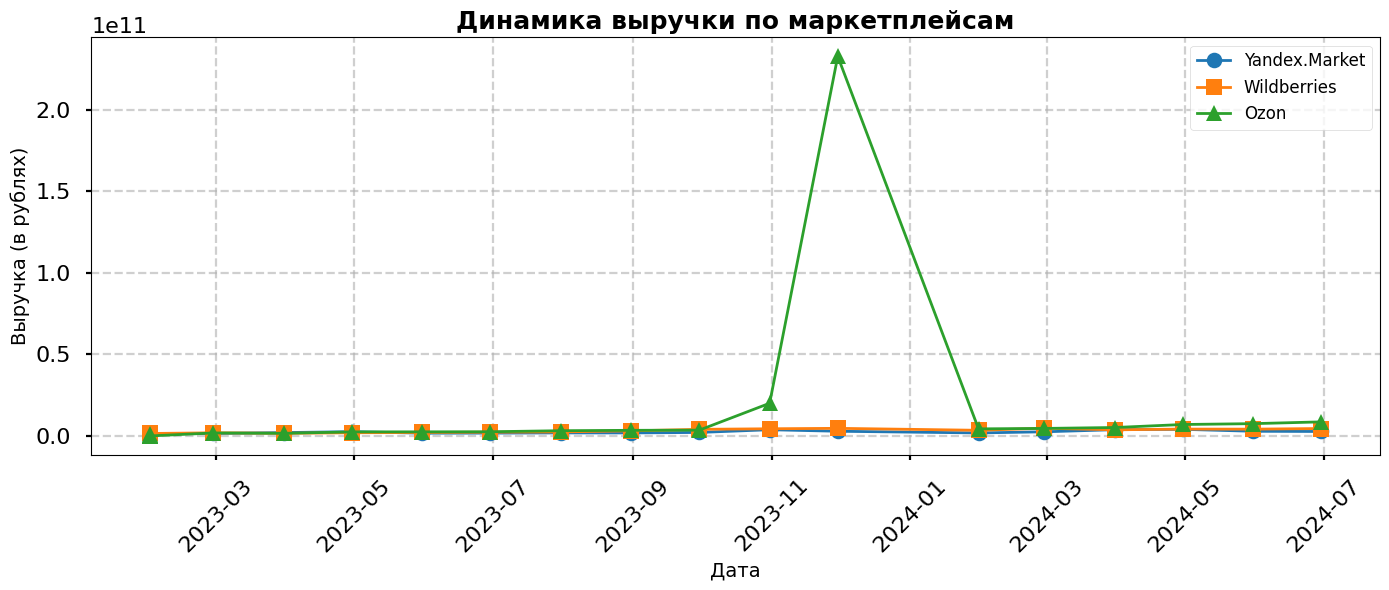

In [600]:
import pandas as pd
import matplotlib.pyplot as plt

# Устанавливаем стиль оформления
plt.style.use('seaborn-v0_8-poster')

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(auto_revenue['date'], auto_revenue['revenue_rub_yand_market'],
        label='Yandex.Market', marker='o', linewidth=2)
ax.plot(auto_revenue['date'], auto_revenue['revenue_rub_wb'],
        label='Wildberries', marker='s', linewidth=2)
ax.plot(auto_revenue['date'], auto_revenue['revenue_rub_ozon'],
        label='Ozon', marker='^', linewidth=2)

# Оформление
ax.set_title('Динамика выручки по маркетплейсам', fontsize=18, weight='bold')
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Выручка (в рублях)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Отображение графика
plt.show()


## Аптека

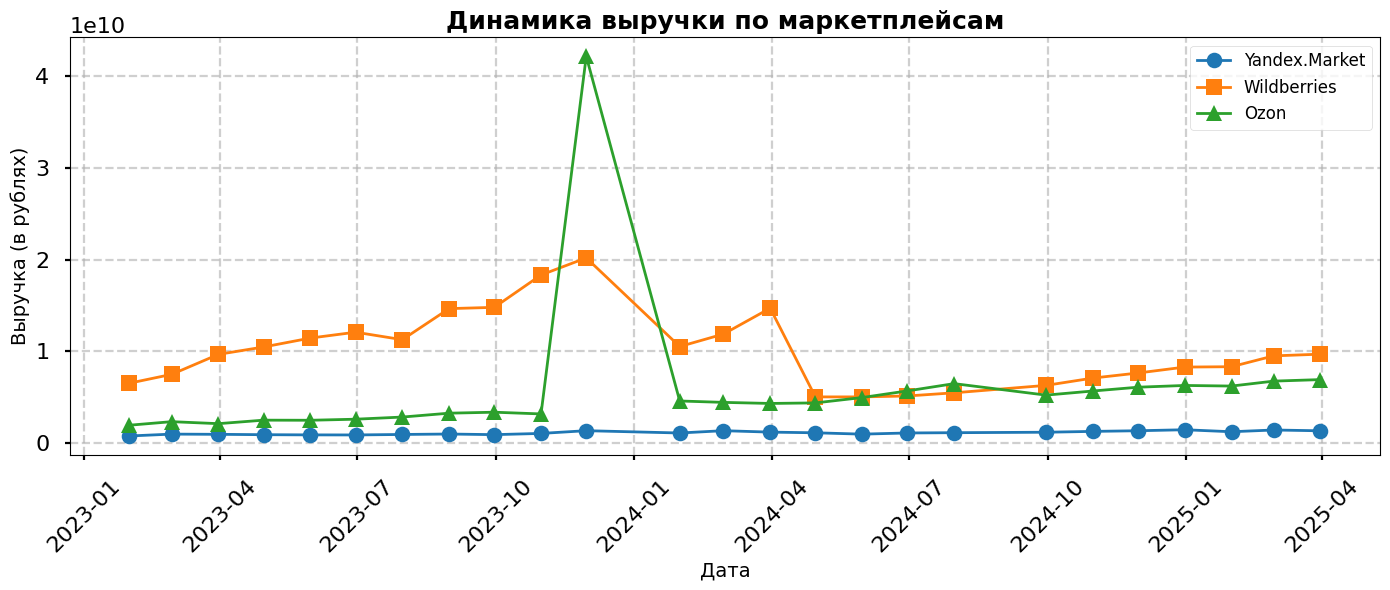

In [601]:
apteka_revenue = final_df[final_df['category']=='Аптека']
apteka_revenue

# Устанавливаем стиль оформления
plt.style.use('seaborn-v0_8-poster')

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(apteka_revenue['date'], apteka_revenue['revenue_rub_yand_market'],
        label='Yandex.Market', marker='o', linewidth=2)
ax.plot(apteka_revenue['date'], apteka_revenue['revenue_rub_wb'],
        label='Wildberries', marker='s', linewidth=2)
ax.plot(apteka_revenue['date'], apteka_revenue['revenue_rub_ozon'],
        label='Ozon', marker='^', linewidth=2)

# Оформление
ax.set_title('Динамика выручки по маркетплейсам', fontsize=18, weight='bold')
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Выручка (в рублях)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Отображение графика
plt.show()

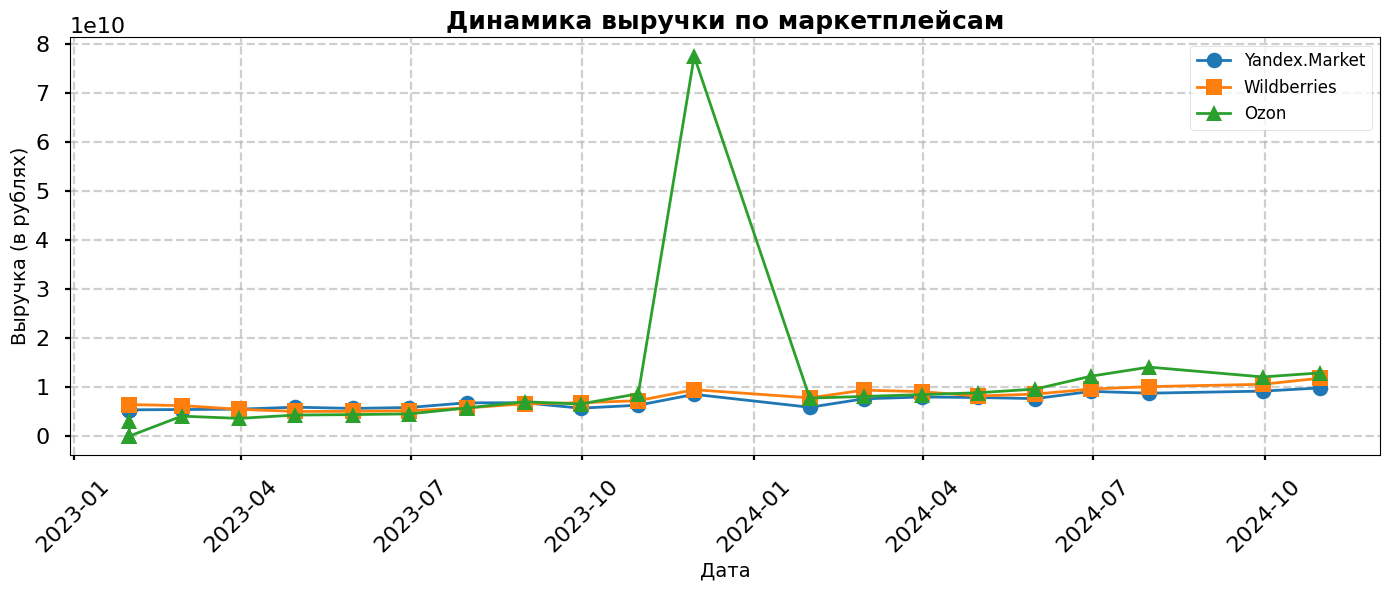

In [602]:
tech_revenue = final_df[final_df['category']=='Бытовая техника']
tech_revenue

# Устанавливаем стиль оформления
plt.style.use('seaborn-v0_8-poster')

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(tech_revenue['date'], tech_revenue['revenue_rub_yand_market'],
        label='Yandex.Market', marker='o', linewidth=2)
ax.plot(tech_revenue['date'], tech_revenue['revenue_rub_wb'],
        label='Wildberries', marker='s', linewidth=2)
ax.plot(tech_revenue['date'], tech_revenue['revenue_rub_ozon'],
        label='Ozon', marker='^', linewidth=2)

# Оформление
ax.set_title('Динамика выручки по маркетплейсам', fontsize=18, weight='bold')
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Выручка (в рублях)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Отображение графика
plt.show()


## Книги

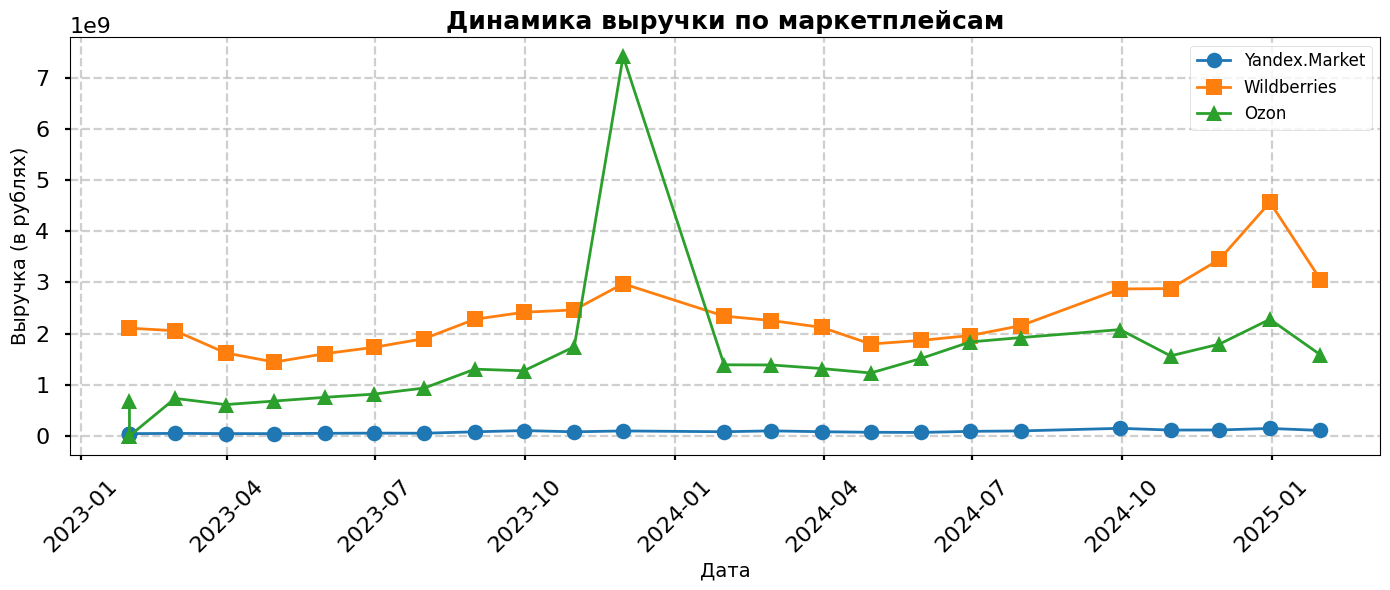

In [603]:
books_revenue = final_df[final_df['category']=='Книги']
books_revenue

# Устанавливаем стиль оформления
plt.style.use('seaborn-v0_8-poster')

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(books_revenue['date'], books_revenue['revenue_rub_yand_market'],
        label='Yandex.Market', marker='o', linewidth=2)
ax.plot(books_revenue['date'], books_revenue['revenue_rub_wb'],
        label='Wildberries', marker='s', linewidth=2)
ax.plot(books_revenue['date'], books_revenue['revenue_rub_ozon'],
        label='Ozon', marker='^', linewidth=2)

# Оформление
ax.set_title('Динамика выручки по маркетплейсам', fontsize=18, weight='bold')
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Выручка (в рублях)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Отображение графика
plt.show()


## Продукты

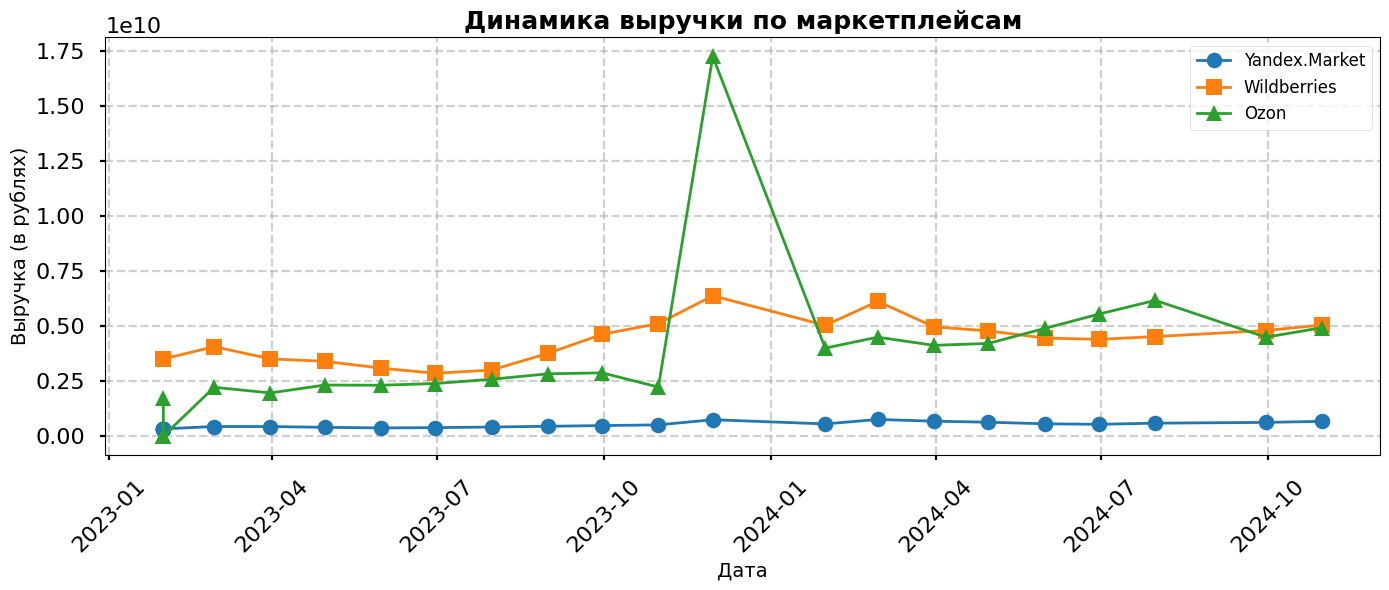

In [604]:
products_revenue = final_df[final_df['category']=='Продукты']
products_revenue

# Устанавливаем стиль оформления
plt.style.use('seaborn-v0_8-poster')

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(products_revenue['date'], products_revenue['revenue_rub_yand_market'],
        label='Yandex.Market', marker='o', linewidth=2)
ax.plot(products_revenue['date'], products_revenue['revenue_rub_wb'],
        label='Wildberries', marker='s', linewidth=2)
ax.plot(products_revenue['date'], products_revenue['revenue_rub_ozon'],
        label='Ozon', marker='^', linewidth=2)

# Оформление
ax.set_title('Динамика выручки по маркетплейсам', fontsize=18, weight='bold')
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Выручка (в рублях)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Отображение графика
plt.show()


## Спорт и отдых

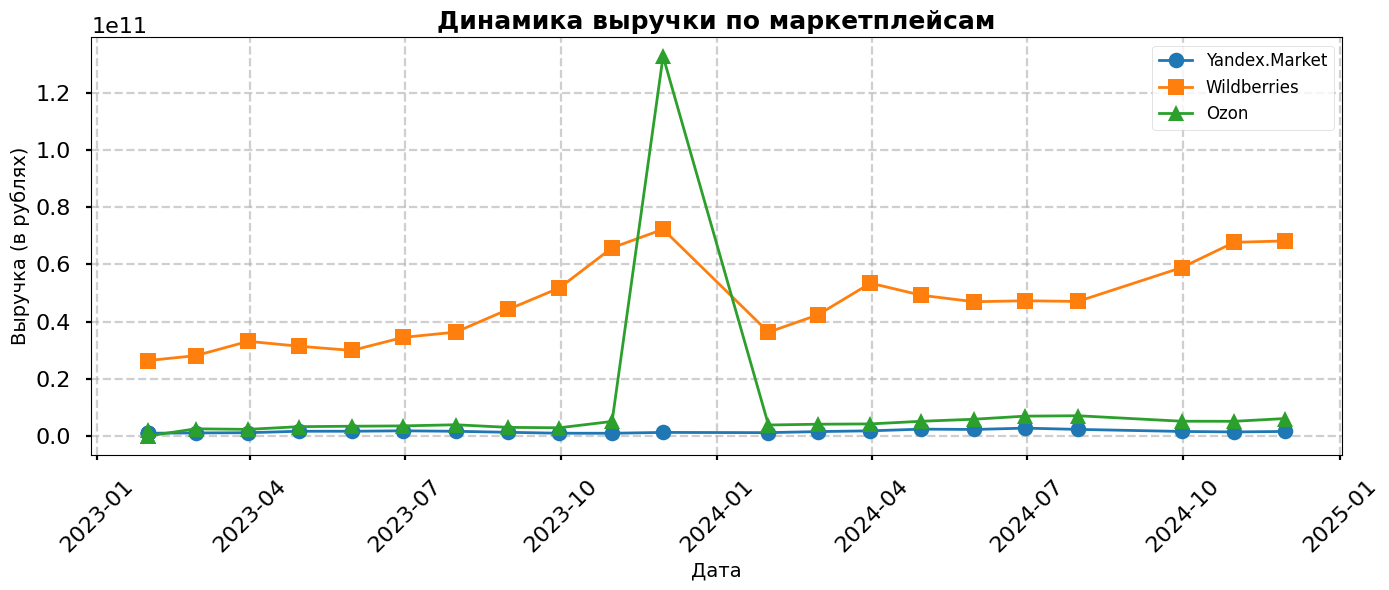

In [605]:
sport_revenue = final_df[final_df['category']=='Спорт и отдых']
sport_revenue

# Устанавливаем стиль оформления
plt.style.use('seaborn-v0_8-poster')

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(sport_revenue['date'], sport_revenue['revenue_rub_yand_market'],
        label='Yandex.Market', marker='o', linewidth=2)
ax.plot(sport_revenue['date'], sport_revenue['revenue_rub_wb'],
        label='Wildberries', marker='s', linewidth=2)
ax.plot(sport_revenue['date'], sport_revenue['revenue_rub_ozon'],
        label='Ozon', marker='^', linewidth=2)

# Оформление
ax.set_title('Динамика выручки по маркетплейсам', fontsize=18, weight='bold')
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Выручка (в рублях)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Отображение графика
plt.show()


## Зоотовары

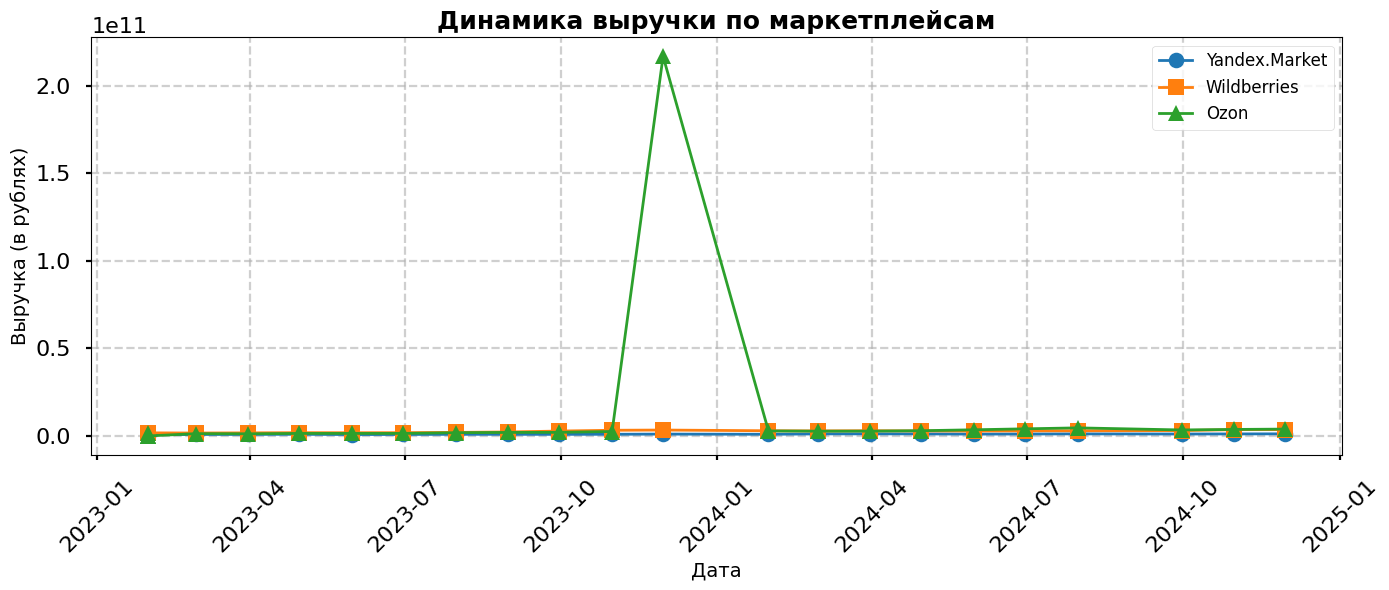

In [606]:
zoo_revenue = final_df[final_df['category']=='Зоотовары']
zoo_revenue

# Устанавливаем стиль оформления
plt.style.use('seaborn-v0_8-poster')

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(zoo_revenue['date'], zoo_revenue['revenue_rub_yand_market'],
        label='Yandex.Market', marker='o', linewidth=2)
ax.plot(zoo_revenue['date'], zoo_revenue['revenue_rub_wb'],
        label='Wildberries', marker='s', linewidth=2)
ax.plot(zoo_revenue['date'], zoo_revenue['revenue_rub_ozon'],
        label='Ozon', marker='^', linewidth=2)

# Оформление
ax.set_title('Динамика выручки по маркетплейсам', fontsize=18, weight='bold')
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Выручка (в рублях)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Отображение графика
plt.show()


## Электроника

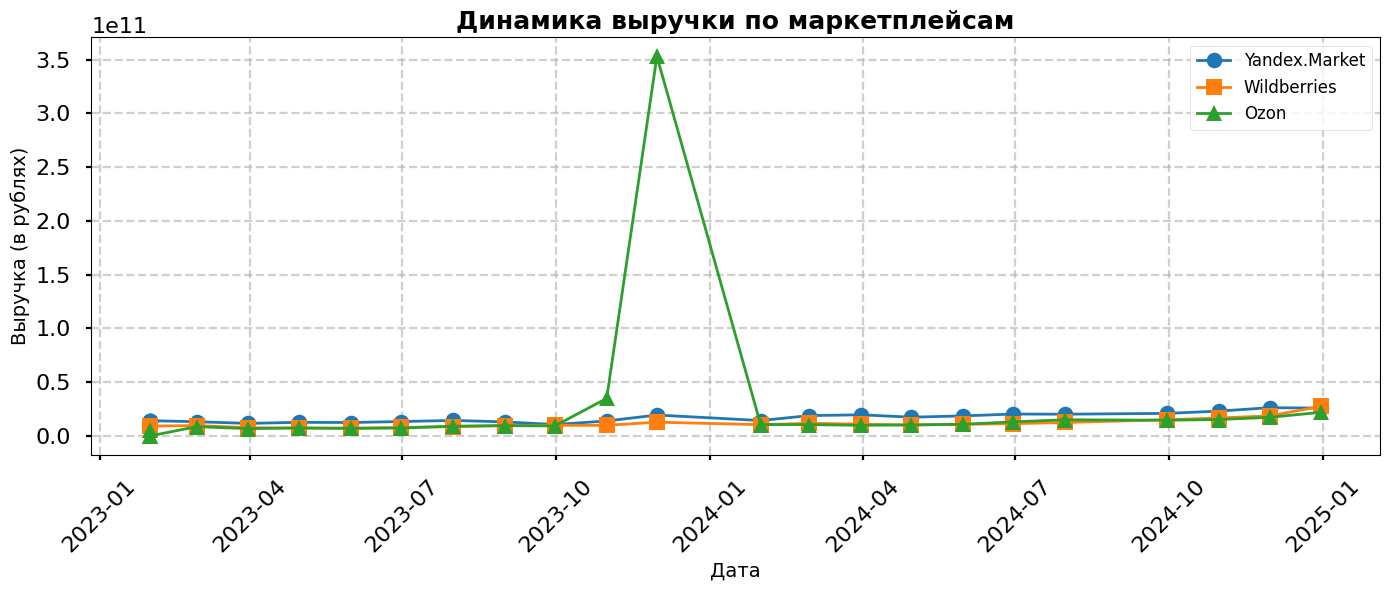

In [607]:
electr_revenue = final_df[final_df['category']=='Электроника']
electr_revenue

# Устанавливаем стиль оформления
plt.style.use('seaborn-v0_8-poster')

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(electr_revenue['date'], electr_revenue['revenue_rub_yand_market'],
        label='Yandex.Market', marker='o', linewidth=2)
ax.plot(electr_revenue['date'], electr_revenue['revenue_rub_wb'],
        label='Wildberries', marker='s', linewidth=2)
ax.plot(electr_revenue['date'], electr_revenue['revenue_rub_ozon'],
        label='Ozon', marker='^', linewidth=2)

# Оформление
ax.set_title('Динамика выручки по маркетплейсам', fontsize=18, weight='bold')
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Выручка (в рублях)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Отображение графика
plt.show()

На всех графиках виден резкий скачок выручки для маркетплейса OZON в конце 2023 - начале 2024, такой скачок маловероятен и связан с ошибкой в данных. Наибольшая вырука почти во всех категориях у Wildberries, за которым следует Ozon, однако в категориях связанных с бытовой техникой и электроникой лидирует Яндекс Маркет.